# 1. Problem Definition

Recently, many of you have emailed me asking how to build an Orbit Comp baseline.  

This notebook helps you create your own baseline using a quiz.   

> You grow your agent by solving small missions one by one.  

You begin with basic steps and develop your strategy gradually.

Start by answering these five questions:

- (1) Where is my planet?
- (2) Which target can I shoot?
- (3) Where will the moving planet be when I arrive?
- (4) Is this a safe shot that avoids the sun?
- (5) What seems like the best action right now?

Solving these five questions in code gives you the basic Orbit Comp baseline.

In [ ]:
import os
import sys
import json
import math

ENGINE_PATH = "/kaggle/input/datasets/woosungyoon/orbit-comp-mission"
sys.path.insert(0, ENGINE_PATH)

from orbit_comp_mission_engine import (
    list_missions,
    mission_path,
    load_mission_data,
    run_mission,
    run_and_show_mission,
    display_mission_replay,
    print_replay,
    replay_dataframe,
)

print("Available missions:\n" + '\n'.join(list_missions()))

---

# 2. Quiz (Subproblems)

## 2.1. Mission 1 - Mission 3

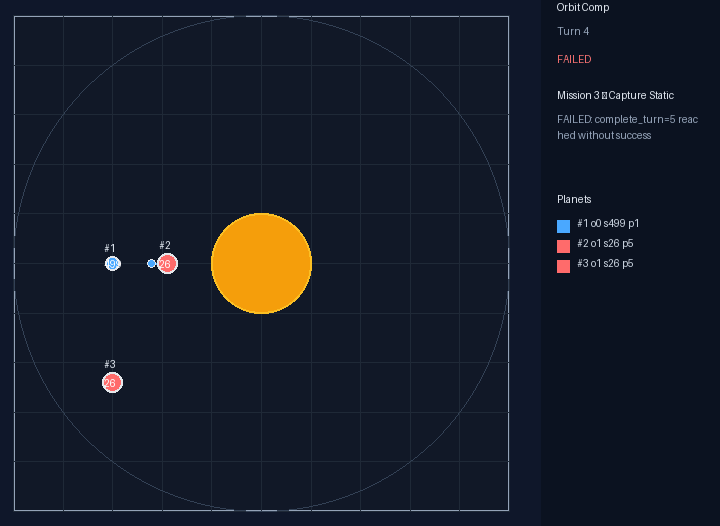
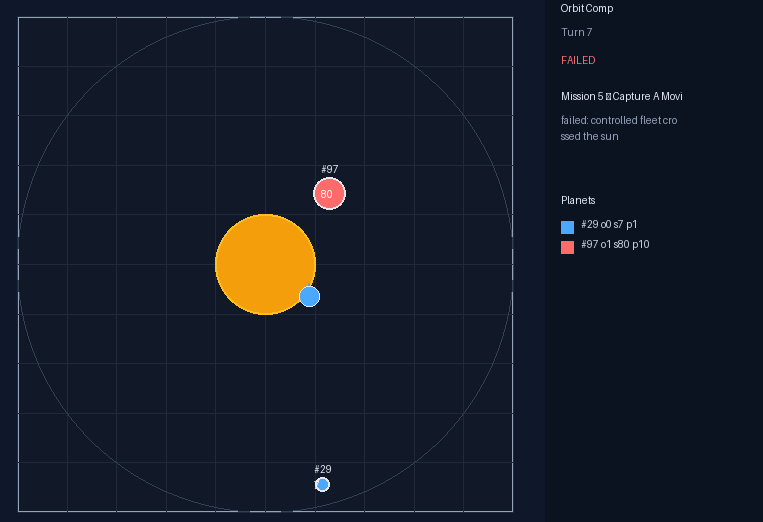

## Mission 1 — Find My Planets

The first mission is to find the planets owned by your player.

Your agent receives an `obs` dictionary. The most important field for this mission is:

```python
obs["planets"]
```

Each planet is represented as:

```python
[id, owner, x, y, radius, ships, production]
```

Your task is simple: find every planet where `owner == obs["player"]`, and submit an action from those planets only.

### Task

Complete the `agent()` function below.

A launch action has this format:

```python
[source_planet_id, angle_radians, ships]
```

In [ ]:
%%writefile mission_01_agent.py
import math


def agent(obs):
    if obs.get("step", 0) > 0:
        return []

    player = obs["player"]
    planets = obs["planets"]
    actions = []

    for planet in planets:
        planet_id, owner, x, y, radius, ships, production = planet
        is_my_planet = owner == player

        # TODO FIX:
        # This action is currently added for every planet.
        # Change the code so that it only launches from my planets.
        if ships >= 1:
            actions.append([planet_id, 0.0, 1])

    return actions

In [ ]:
MISSION_NAME = "mission_01_find_my_planets"
AGENT_PATH = "mission_01_agent.py"
REPLAY_PATH = "mission_01_wrong.gif"

result = run_and_show_mission(
    mission_path(MISSION_NAME),
    player_agent_path=AGENT_PATH,
    enemy_agent_path=None,
    replay_output_path=REPLAY_PATH,
    replay_fps=2,
)

---

# Mission 2 — Find Targets

The second mission is to find target candidates.

The simplest target rule is:

> A target candidate is any planet that is **not owned by me**.

This includes enemy planets and neutral planets.

In this mission, your agent should choose one owned source planet, choose one target candidate, and aim toward it.

## Task

Complete two small pieces:

1. `my_planets`: planets where `owner == player`
2. `targets`: planets where `owner != player`

Then return one action that points from a source planet toward a target candidate.

In [ ]:
%%writefile mission_02_agent.py
import math


def angle_to(source, target):
    return math.atan2(target[3] - source[3], target[2] - source[2])


def agent(obs):
    if obs.get("step", 0) > 0:
        return []

    player = obs["player"]
    planets = obs["planets"]
    my_planets = []
    targets = []

    for planet in planets:
        planet_id, owner, x, y, radius, ships, production = planet

        if owner == player:
            my_planets.append(planet)

        # TODO FIX:
        # This only keeps the first target candidate.
        # Mission 2 requires an action aimed at EVERY target candidate.
        if owner != player and len(targets) == 0:
            targets.append(planet)

    if not my_planets or not targets:
        return []

    source = my_planets[0]
    actions = []
    for target in targets:
        actions.append([source[0], angle_to(source, target), 1])

    return actions


In [ ]:
MISSION_NAME = 'mission_02_find_targets'
AGENT_PATH = 'mission_02_agent.py'
REPLAY_PATH = 'mission_02_wrong.gif'

result = run_and_show_mission(
    mission_path(MISSION_NAME),
    player_agent_path=AGENT_PATH,
    enemy_agent_path=None,
    replay_output_path=REPLAY_PATH,
    replay_fps=2,
)

---

# Mission 3 — Hit A Static Target

The third mission is to hit a target that does not move.

The basic aiming rule is:

```python
angle = atan2(target_y - source_y, target_x - source_x)
```

For a static target, this is usually enough.

The mission succeeds when a fleet owned by player `0` hits planet `2`.

## Task

Complete the agent so it launches from your owned planet toward the nearby target planet.

This mission map has one close enemy target and one far enemy target. The close target is intended to be hit within five turns.

In [ ]:
%%writefile mission_03_agent.py
import math


def angle_to(source, target):
    return math.atan2(target[3] - source[3], target[2] - source[2])


def agent(obs):
    if obs.get("step", 0) > 0:
        return []

    player = obs["player"]
    planets = obs["planets"]
    source = next((p for p in planets if p[1] == player), None)
    target = next((p for p in planets if p[1] != player), None)

    if source is None or target is None:
        return []

    # TODO FIX:
    # This only attacks one target and sends too few ships.
    # Mission 3 requires capturing ALL enemy targets within five turns.
    ships = 5

    return [[source[0], angle_to(source, target), ships]]


In [ ]:
MISSION_NAME = 'mission_03_hit_static_target'
AGENT_PATH = 'mission_03_agent.py'
REPLAY_PATH = 'mission_03_wrong.gif'

result = run_and_show_mission(
    mission_path(MISSION_NAME),
    player_agent_path=AGENT_PATH,
    enemy_agent_path=None,
    replay_output_path=REPLAY_PATH,
    replay_fps=2,
)


---

## 2.2 Mission 4 - Mission 5

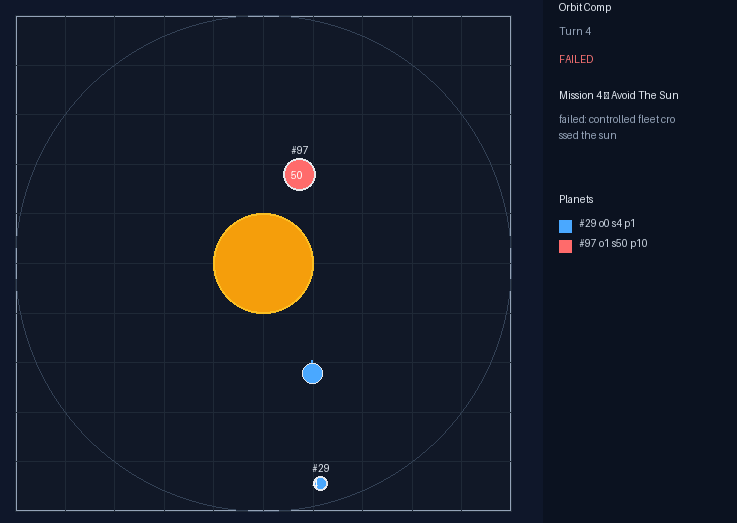

# Mission 4 — Avoid The Sun

The fourth mission is about safety.

A target direction may look good, but a direct path can cross the sun. In Orbit Comp, a fleet that crosses the sun is lost.

Before submitting a launch, your agent should test whether the segment from the launch point to a future point crosses the sun.

This mission succeeds when you launch at least one fleet and no controlled fleet is lost to the sun.

## Task

Implement `segment_crosses_sun()` and use it before choosing an action.

For this beginner mission, it is okay to scan several angles and choose the first angle that does not cross the sun.

In [ ]:
%%writefile mission_04_agent.py
import math

TARGET_ID = 97


def angle_to(source, target):
    return math.atan2(target[3] - source[3], target[2] - source[2])


def agent(obs):
    if obs.get("step", 0) > 0:
        return []

    player = obs["player"]
    planets = obs["planets"]
    source = next((p for p in planets if p[1] == player), None)
    target = next((p for p in planets if p[0] == TARGET_ID), None)

    if source is None or target is None:
        return []

    # TODO FIX:
    # The direct angle crosses the sun in this mission.
    angle = angle_to(source, target)
    ships = min(source[5], 500)

    return [[source[0], angle, ships]]


In [ ]:
MISSION_NAME = 'mission_04_avoid_the_sun'
AGENT_PATH = 'mission_04_agent.py'
REPLAY_PATH = 'mission_04_wrong.gif'

result = run_and_show_mission(
    mission_path(MISSION_NAME),
    player_agent_path=AGENT_PATH,
    enemy_agent_path=None,
    replay_output_path=REPLAY_PATH,
    replay_fps=2,
)

---

# Mission 5 — Hit A Moving Planet

The fifth mission is to hit a moving planet.

If you aim at the target's current position, the shot can miss. A simple improvement is:

1. Estimate the travel time to the current target position.
2. Predict where the target will be at that arrival time.
3. Aim at the predicted position.
4. Repeat a few times.

This is the first real aiming loop.

## Task

Complete `predict_orbit_position()` and use it inside `aim_with_prediction()`.

The mission target is planet `97`. It orbits around the board center.

In [ ]:
%%writefile mission_05_agent.py
import math

TARGET_ID = 97


def angle_to(source, target):
    return math.atan2(target[3] - source[3], target[2] - source[2])


def agent(obs):
    if obs.get("step", 0) > 0:
        return []

    player = obs["player"]
    planets = obs["planets"]
    source = next((p for p in planets if p[1] == player), None)
    target = next((p for p in planets if p[0] == TARGET_ID), None)

    if source is None or target is None:
        return []

    # TODO FIX:
    # This aims at the current position of a moving planet.
    ships = min(source[5], 500)
    return [[source[0], angle_to(source, target), ships]]


In [ ]:
MISSION_NAME = 'mission_05_hit_moving_planet'
AGENT_PATH = 'mission_05_agent.py'
REPLAY_PATH = 'mission_05_wrong.gif'

result = run_and_show_mission(
    mission_path(MISSION_NAME),
    player_agent_path=AGENT_PATH,
    enemy_agent_path=None,
    replay_output_path=REPLAY_PATH,
    replay_fps=2,
)


---

# 3. Conclusion

Start with the simplest possible agent.

Then watch the replay carefully and ask yourself one question:

> What is the first thing my agent is doing wrong?

Improve only one thing at a time.  
An agent is rarely built by adding many complicated rules at once. It is built by repeating this simple loop:

1. Make one simple decision.
2. Run the mission.
3. Watch the replay.
4. Find one visible mistake.
5. Improve one function.
6. Test again.

Visualization is more powerful than guessing.  
The good ideas may come from the careful observation of the game.

---

# Note

I tried to answer the question of how to create a baseline.

Thanks.